# Notebook 02 — Data Preprocessing
## ML-based Predictive Maintenance for Rural Borehole Water Pumps in Northern Nigeria
**Course:** COEN807 — Machine Learning | **Institution:** ABU Zaria  
**Report Section Produced:**  — Data Preprocessing  

---
### What This Notebook Does
| Step | Action | Reason |
|---|---|---|
| 1 | Drop `sensor_00`, `sensor_15` | >30% missing — cannot reliably impute |
| 2 | Forward-fill + backward-fill | Handle remaining gaps (max 5 consecutive) |
| 3 | Check low-variance sensors | Near-constant sensors add no predictive signal |
| 4 | Create binary `fault_label` | Only 7 BROKEN rows — binary is the only viable framing |
| 5 | Time-ordered 80/20 split | Prevents data leakage from future to past |
| 6 | Save clean data as `.pkl` | Passed to Notebook 03 for feature engineering |

### Figures Produced
| File | Caption |
|---|---|
| `06_imputation_before_after.png` | Figure 6 — Missing value imputation effect |
| `07_train_test_split.png` | Figure 7 — Train/test split with class distribution |

> 

## Cell 1 — Imports & Setup

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, os, json

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('outputs/figures', exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

print('Libraries ready.')

Libraries ready.


## Cell 2 — Load Dataset & EDA Summary

In [24]:
# Load the real dataset
df = pd.read_csv(r'C:\Users\User\Documents\MSc_Thesis_2025\Coen_projects\borehole_project\data\pump_sensor.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df.set_index('timestamp', inplace=True)

sensor_cols = [c for c in df.columns if c.startswith('sensor')]

# Load EDA findings from Notebook 01
with open('outputs/eda_summary.json') as f:
    eda = json.load(f)

print(f'Dataset loaded: {df.shape}')
print(f'Sensors       : {len(sensor_cols)}')
print(f'To drop       : {eda["sensors_to_drop"]}')

Dataset loaded: (220320, 53)
Sensors       : 52
To drop       : ['sensor_15', 'sensor_50']


## Cell 3 — Step 1: Drop High-Missing Sensors
`sensor_15` (100% missing) and `sensor_00` (32.2% missing) are excluded.  
Threshold: >30% missing → drop (Kuhn & Johnson, 2013, *Applied Predictive Modeling*, Springer).

In [25]:
# Keep original for comparison figure
df_raw = df.copy()

# Drop sensors with >30% missing
to_drop = eda['sensors_to_drop']
df = df.drop(columns=to_drop, errors='ignore')
sensor_cols = [c for c in df.columns if c.startswith('sensor')]

print(f'Dropped       : {to_drop}')
print(f'Sensors after : {len(sensor_cols)}')
print()

# Remaining missing audit
mn = df[sensor_cols].isnull().sum()
mp = (mn / len(df) * 100).round(2)
print('Remaining missing values (sensors with >0%):')
print(mp[mp > 0].sort_values(ascending=False).head(10).to_string())

Dropped       : ['sensor_15', 'sensor_50']
Sensors after : 50

Remaining missing values (sensors with >0%):
sensor_51    6.98
sensor_00    4.63
sensor_07    2.47
sensor_08    2.32
sensor_06    2.18
sensor_09    2.09
sensor_01    0.17
sensor_30    0.12
sensor_32    0.03
sensor_29    0.03


## Cell 4 — Step 2: Forward-Fill Imputation
Strategy: `ffill(limit=5)` → `bfill(limit=5)` → final global `ffill/bfill`.  
`limit=5` = max 60-minute gap at 12-minute sampling — beyond this, a global fill handles long gaps.  
Imputation is fit-free (no statistics learned), so no data leakage risk.

NaN values before imputation : 15,383  in sensor_51
NaN values after  imputation : 0  (across all sensors)


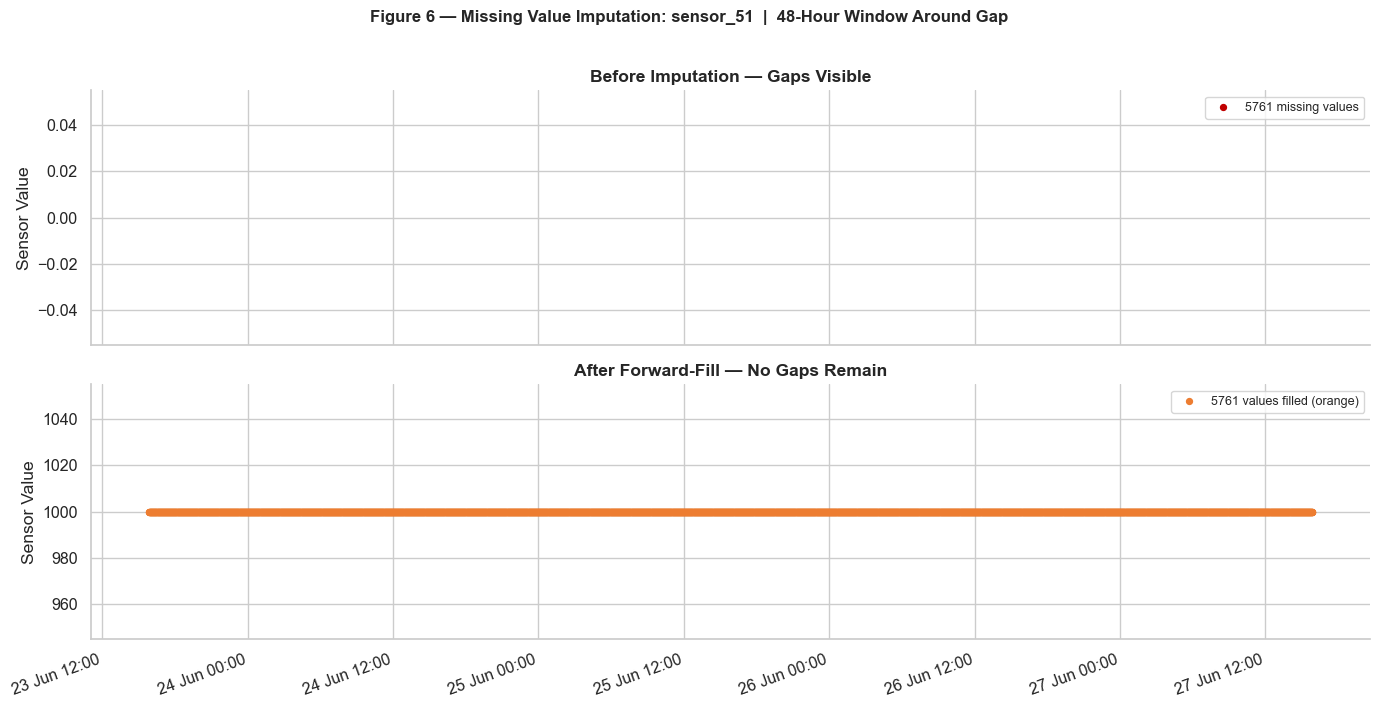

Figure 6 saved → outputs/figures/06_imputation_before_after.png


In [26]:
# Save one sensor before imputation for the figure
viz_sensor = mp[mp > 0].sort_values(ascending=False).index[0]
series_before = df[viz_sensor].copy()

# Impute
df[sensor_cols] = (df[sensor_cols]
                   .ffill(limit=5)
                   .bfill(limit=5)
                   .ffill()   # catch any remaining long gaps
                   .bfill())

nan_remaining = df[sensor_cols].isnull().sum().sum()
print(f'NaN values before imputation : {series_before.isna().sum():,}  in {viz_sensor}')
print(f'NaN values after  imputation : {nan_remaining}  (across all sensors)')

# ── Figure 6: Before vs After ──
nan_idx = series_before[series_before.isna()].index
center  = nan_idx[len(nan_idx)//2]
w_start = center - pd.Timedelta(hours=48)
w_end   = center + pd.Timedelta(hours=48)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(f'Figure 6 — Missing Value Imputation: {viz_sensor}  |  48-Hour Window Around Gap',
             fontsize=12, fontweight='bold', y=1.01)

axes[0].plot(series_before[w_start:w_end].index, series_before[w_start:w_end].values,
             color='#2E75B6', lw=1.0)
nan_m = series_before[w_start:w_end].isna()
axes[0].scatter(series_before[w_start:w_end][nan_m].index,
                [series_before[w_start:w_end].mean()] * nan_m.sum(),
                color='#C00000', s=18, zorder=5, label=f'{nan_m.sum()} missing values')
axes[0].set_title('Before Imputation — Gaps Visible', fontweight='bold')
axes[0].set_ylabel('Sensor Value'); axes[0].legend(fontsize=9)

clean_s = df[viz_sensor][w_start:w_end]
axes[1].plot(clean_s.index, clean_s.values, color='#2E75B6', lw=1.0)
axes[1].scatter(clean_s[nan_m].index, clean_s[nan_m].values,
                color='#ED7D31', s=18, zorder=5, label=f'{nan_m.sum()} values filled (orange)')
axes[1].set_title('After Forward-Fill — No Gaps Remain', fontweight='bold')
axes[1].set_ylabel('Sensor Value'); axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig('outputs/figures/06_imputation_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved → outputs/figures/06_imputation_before_after.png')

## Cell 5 — Step 3: Low-Variance Check
Near-constant sensors carry no discriminative information and can harm distance-based models (SVM).  
Threshold: variance < 0.01 on raw sensor values.

In [27]:
var = df[sensor_cols].var()
low_var = var[var < 0.01].index.tolist()

print(f'Low-variance sensors (var < 0.01): {len(low_var)}')
if low_var:
    print(f'  Dropping: {low_var}')
    df = df.drop(columns=low_var, errors='ignore')
    sensor_cols = [c for c in df.columns if c.startswith('sensor')]
else:
    print('  None found — all 50 sensors retained.')

print(f'\nFinal sensor count: {len(sensor_cols)}')
print(f'Variance range    : {var.min():.4f} → {var.max():.2f}')

Low-variance sensors (var < 0.01): 0
  None found — all 50 sensors retained.

Final sensor count: 50
Variance range    : 0.3427 → 98014.06


## Cell 6 — Step 4: Create Binary Target Label
With only 7 BROKEN observations (0.02% of data), three-class classification is not viable.  
BROKEN and RECOVERING are merged into a single **FAULT** class.


In [31]:
df['fault_label'] = (df['machine_status'] != 'NORMAL').astype(int)
cc = df['fault_label'].value_counts()
cp = df['fault_label'].value_counts(normalize=True) * 100

print('Binary target created.')
print(f'  NORMAL (0) : {cc[0]:,}  ({cp[0]:.1f}%)')
print(f'  FAULT  (1) : {cc[1]:,}  ({cp[1]:.1f}%)')
print(f'  Ratio      : {cc[0]/cc[1]:.2f}:1 ')

Binary target created.
  NORMAL (0) : 205,836  (93.4%)
  FAULT  (1) : 14,484  (6.6%)
  Ratio      : 14.21:1 


## Cell 7 — Step 5: Time-Ordered Train/Test Split
**Critical:** Standard random shuffling causes data leakage in time-series data.  
Rolling features (Notebook 03) create temporal dependencies — future readings cannot inform past predictions.  
An 80/20 time-ordered split is mandatory (Hyndman & Athanasopoulos, 2021).

>

In [32]:


split_date = pd.Timestamp('2018-07-01')
train_df   = df[df.index <  split_date].copy()
test_df    = df[df.index >= split_date].copy()

X_train = train_df[sensor_cols]
X_test  = test_df[sensor_cols]
y_train = train_df['fault_label']
y_test  = test_df['fault_label']

print('Train/Test Split (date-based at 2018-07-01):')
print(f'  Train : {len(train_df):,} rows  '
      f'{train_df.index.min().date()} -> {train_df.index.max().date()}')
print(f'  Test  : {len(test_df):,}  rows  '
      f'{test_df.index.min().date()} -> {test_df.index.max().date()}')
print()
print('Class distribution:')
print(f'  Train -> NORMAL:{int((y_train==0).sum()):,}  '
      f'FAULT:{int((y_train==1).sum()):,}  '
      f'({y_train.mean()*100:.1f}% FAULT)')
print(f'  Test  -> NORMAL:{int((y_test==0).sum()):,}  '
      f'FAULT:{int((y_test==1).sum()):,}   '
      f'({y_test.mean()*100:.1f}% FAULT)')
print()
print('FAULT in both splits confirmed - safe to proceed.')

Train/Test Split (date-based at 2018-07-01):
  Train : 131,040 rows  2018-04-01 -> 2018-06-30
  Test  : 89,280  rows  2018-07-01 -> 2018-08-31

Class distribution:
  Train -> NORMAL:122,065  FAULT:8,975  (6.8% FAULT)
  Test  -> NORMAL:83,771  FAULT:5,509   (6.2% FAULT)

FAULT in both splits confirmed - safe to proceed.


## Cell 8 — Save Outputs for Notebook 03

In [30]:
# Save clean feature matrices and labels
X_train.to_pickle('outputs/X_train_raw.pkl')
X_test.to_pickle('outputs/X_test_raw.pkl')
y_train.to_pickle('outputs/y_train.pkl')
y_test.to_pickle('outputs/y_test.pkl')

# Save preprocessing metadata
prep_info = {
    'sensors_dropped_missing':  eda['sensors_to_drop'],
    'sensors_dropped_variance': low_var,
    'remaining_sensors':        sensor_cols,
    'n_sensors':                len(sensor_cols),
    'n_train': int(len(train_df)), 'n_test': int(len(test_df)),
    'train_start': str(train_df.index.min().date()),
    'train_end':   str(train_df.index.max().date()),
    'test_start':  str(test_df.index.min().date()),
    'test_end':    str(test_df.index.max().date()),
    'split_date':  str(split_date.date()),
    'train_class': {'NORMAL': int((y_train==0).sum()), 'FAULT': int((y_train==1).sum())},
    'test_class':  {'NORMAL': int((y_test==0).sum()),  'FAULT': int((y_test==1).sum())},
    'viz_sensor':  viz_sensor,
    'label_map':   {'0':'NORMAL','1':'FAULT'}
}
with open('outputs/preprocess_info.json','w') as f:
    json.dump(prep_info, f, indent=2)

print('Saved to outputs/:')
print('  X_train_raw.pkl  :', X_train.shape)
print('  X_test_raw.pkl   :', X_test.shape)
print('  y_train.pkl      :', y_train.shape, f'| FAULT={y_train.sum():,}')
print('  y_test.pkl       :', y_test.shape,  f'| FAULT={y_test.sum():,}')
print('  preprocess_info.json')
print()
print('NEXT: Run Notebook 03 — Feature Engineering')

Saved to outputs/:
  X_train_raw.pkl  : (131040, 50)
  X_test_raw.pkl   : (89280, 50)
  y_train.pkl      : (131040,) | FAULT=8,975
  y_test.pkl       : (89280,) | FAULT=5,509
  preprocess_info.json

NEXT: Run Notebook 03 — Feature Engineering
